# Strands Agents with Bedrock AgentCore Browser

This lab demonstrates how to use Amazon Bedrock AgentCore Browser to navigate financial websites and extract regulatory data.

## Overview

In this lab, you will:
- Create a custom browser with public network access
- Navigate the Reserve Bank of Australia (RBA) website
- Extract monetary policy information
- Read RBA Board meeting minutes

## Why Browser Automation for FSI?

- **Regulatory monitoring** — Check central bank decisions, policy changes
- **Data extraction** — Pull rates, statistics from financial portals
- **Compliance evidence** — Automated proof of monitoring activities
- **Legacy systems** — Interact with web apps that have no API

## Prerequisites

In [ ]:
import os
#os.environ['AWS_ACCESS_KEY_ID'] = ''
#os.environ['AWS_SECRET_ACCESS_KEY'] = ''
#os.environ['AWS_SESSION_TOKEN'] = ''
#os.environ['AWS_REGION'] = ''

In [ ]:
#%pip install -q strands-agents strands-agents-tools rich bedrock-agentcore playwright

In [28]:
import boto3
region = boto3.session.Session().region_name
NOVA_PRO_MODEL_ID = 'us.amazon.nova-pro-v1:0'
if region.startswith('eu'): NOVA_PRO_MODEL_ID = 'eu.amazon.nova-pro-v1:0'
elif region.startswith('ap'): NOVA_PRO_MODEL_ID = 'apac.amazon.nova-pro-v1:0'
print(f'Region: {region}, Model: {NOVA_PRO_MODEL_ID}')

Region: ap-southeast-2, Model: apac.amazon.nova-pro-v1:0


## What is Bedrock AgentCore Browser?

Amazon Bedrock AgentCore Browser is a powerful tool that enables AI agents to interact with web browsers dynamically in a secure, managed environment. Key capabilities include:

- **Web Navigation**: Navigate to websites, click elements, and fill forms programmatically
- **Content Extraction**: Extract information from web pages and capture screenshots
- **Secure Environment**: Runs in an isolated, secure browser environment
- **JavaScript Execution**: Execute custom JavaScript for advanced web interactions
- **Session Management**: Maintain browser sessions across multiple operations

The Browser tool enables agents to perform complex web-based tasks that require visual understanding and interactive capabilities.


## Step 1: Create a Custom Browser with Public Network

The default browser has restrictive settings. For accessing external financial sites, we create a **custom browser** with public network access.

In [29]:
from bedrock_agentcore._utils import endpoints
import boto3
from botocore.exceptions import ClientError

region = boto3.session.Session().region_name
cp_endpoint = endpoints.get_control_plane_endpoint(region)

cp_client = boto3.client('bedrock-agentcore-control', region_name=region, endpoint_url=cp_endpoint)

browser_name = 'fsi_regulatory_browser'
try:
    response = cp_client.create_browser(
        name=browser_name,
        description='Custom browser for FSI regulatory site monitoring',
        networkConfiguration={'networkMode': 'PUBLIC'},
    )
    browser_id = response['browserId']
    print(f'✅ Custom browser created: {browser_id}')
except ClientError as e:
    if 'already exists' in str(e).lower() or 'Conflict' in str(e):
        browsers = cp_client.list_browsers()['browserSummaries']
        browser_id = next(b['browserId'] for b in browsers if b.get('name') == browser_name)
        print(f'✅ Using existing browser: {browser_id}')
    else:
        raise e

print(f'   Network: PUBLIC (can access any website)')

✅ Using existing browser: fsi_regulatory_browser-TOPzdqpjcy
   Network: PUBLIC (can access any website)


## Step 2: Navigate RBA — Cash Rate Target

Let's explore the AgentCore Browser without any agentic environment. We use the Playwright library to connect to the remote browser session.

Once connected, we interact with the page elements as if we're a real user — navigate to the RBA website, wait for the cash rate table to load, and extract the rate history.

In [30]:
from bedrock_agentcore.tools.browser_client import browser_session
from playwright.async_api import async_playwright
import asyncio

with browser_session(region, identifier=browser_id) as client:
    print(f'🌐 Using AgentCore Browser Session: {client.session_id}')
    ws_url, headers = client.generate_ws_headers()

    async with async_playwright() as playwright:
        # Connect to the remote browser
        browser = await playwright.chromium.connect_over_cdp(endpoint_url=ws_url, headers=headers)
        print('✅ Browser connected')

        context = browser.contexts[0] if browser.contexts else await browser.new_context()
        page = context.pages[0] if context.pages else await context.new_page()

        # Step 1: Navigate to the RBA Cash Rate page
        await page.goto('https://www.rba.gov.au/statistics/cash-rate/', timeout=30000)
        await page.wait_for_load_state('domcontentloaded')
        await asyncio.sleep(8)  # Wait for the interactive table to render
        print(f'📄 Page loaded: {await page.title()}')

        # Step 2: Extract the full page content
        content = await page.inner_text('body')

        # Step 3: Parse the cash rate table from the content
        lines = content.split('\n')
        rate_changes = [l.strip() for l in lines if '\t' in l and '202' in l and ('+' in l or '-' in l or '0.00' in l)]

        print('\n📊 Cash Rate History (extracted from RBA):')
        print(f'{"Date":<15} {"Change":<10} {"Rate"}')
        print('-' * 40)
        for row in rate_changes[:5]:
            parts = row.split('\t')
            if len(parts) >= 3:
                print(f'{parts[0]:<15} {parts[1]:<10} {parts[2]}')

        print(f'\n✅ Current cash rate target: {rate_changes[0].split(chr(9))[2] if rate_changes else "Not found"}%')

        await browser.close()


🌐 Using AgentCore Browser Session: 01KT3692Q5FJME9ACRTDJ9JC9W
✅ Browser connected
📄 Page loaded: Cash Rate Target | RBA

📊 Cash Rate History (extracted from RBA):
Date            Change     Rate
----------------------------------------
6 May 2026      +0.25      4.35
18 Mar 2026     +0.25      4.10
4 Feb 2026      +0.25      3.85
10 Dec 2025     0.00       3.60
5 Nov 2025      0.00       3.60

✅ Current cash rate target: 4.35%


## Step 3: Read RBA Board Meeting Minutes

Let's navigate to the latest Monetary Policy Board meeting minutes and extract the key decisions.

🔄 Navigating to RBA Monetary Policy Board Minutes 2026

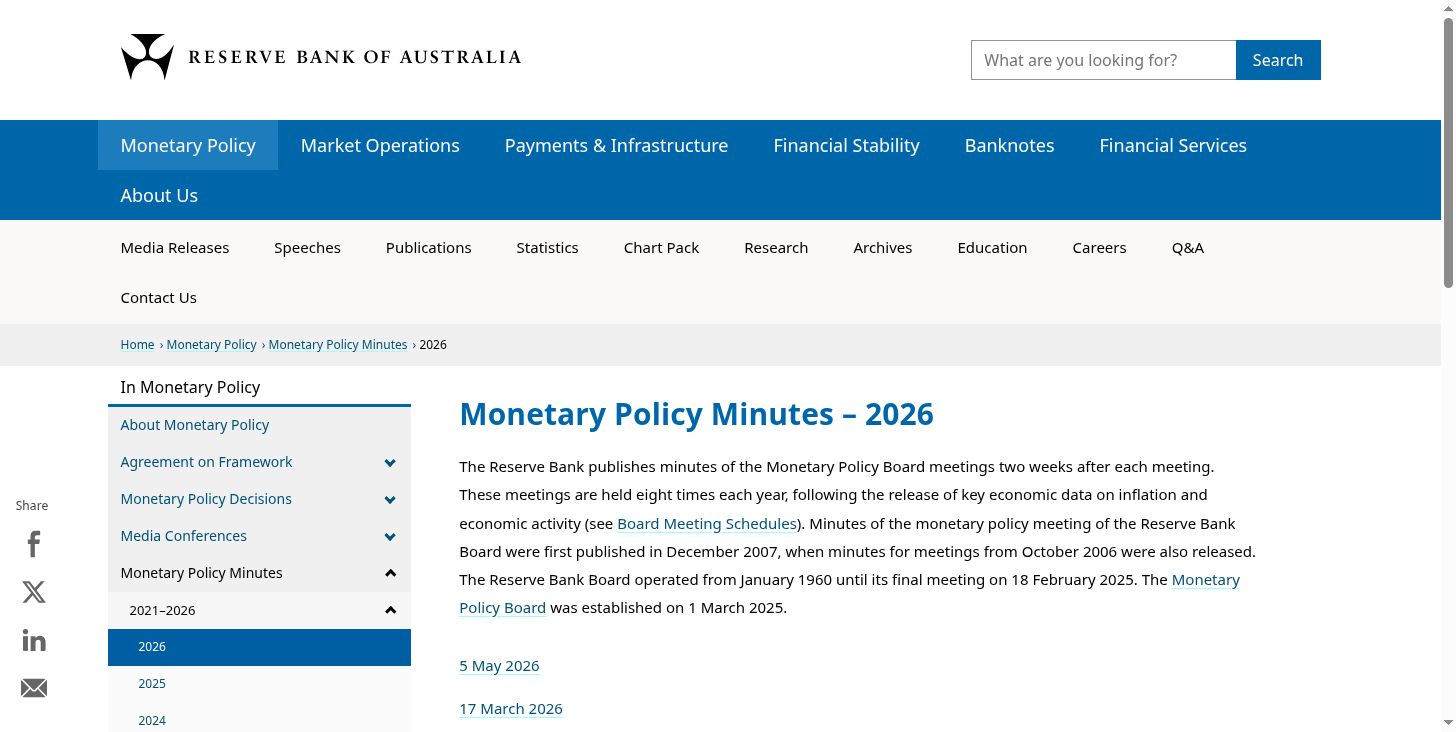

🔄 Clicking on the most recent meeting minutes

Found: 5 May 2026

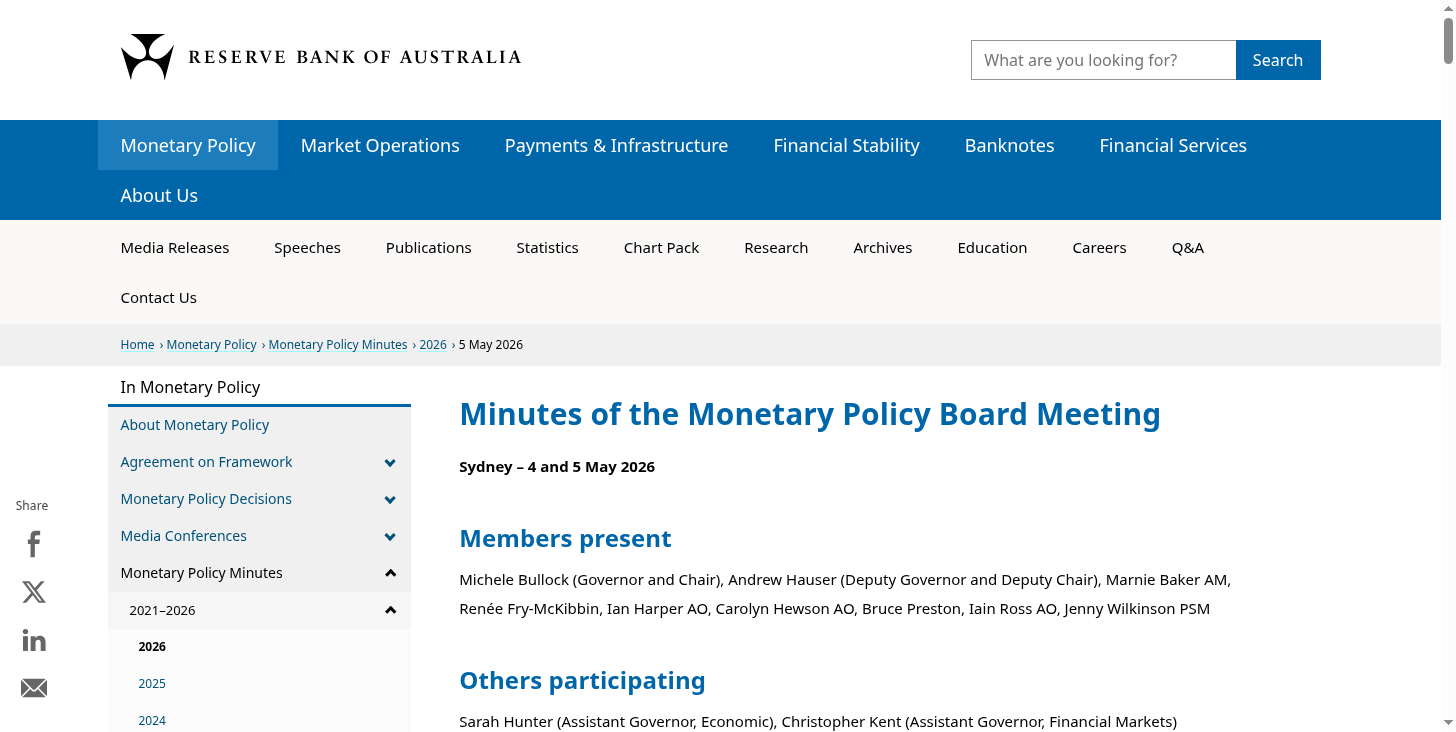

🔄 Extracting The Decision section

--- The Decision ---

the decision would give the Board space to see how the conflict in the Middle East develops and Australian 
households and businesses respond. They also agreed that any assessment of how the incoming data could change the 
outlook should acknowledge that monetary policy could not alter the near-term trajectory of inflation and, 
additionally, that output growth would likely be lower than potential growth for some time.

In finalising its statement, the Board agreed to remain attentive to the data a

In [31]:
from IPython.display import display_jpeg
import rich

console = rich.get_console()

with browser_session(region, identifier=browser_id) as client:
    ws_url, headers = client.generate_ws_headers()

    async with async_playwright() as playwright:
        browser = await playwright.chromium.connect_over_cdp(endpoint_url=ws_url, headers=headers)
        context = browser.contexts[0] if browser.contexts else await browser.new_context()
        page = context.pages[0] if context.pages else await context.new_page()

        # Step 1: Navigate to RBA Board Minutes 2026 index
        console.print('[cyan]🔄 Navigating to RBA Monetary Policy Board Minutes 2026[/cyan]')
        await page.goto('https://www.rba.gov.au/monetary-policy/rba-board-minutes/2026/', timeout=30000)
        await page.wait_for_timeout(5000)
        display_jpeg(await page.screenshot(), raw=True)

        # Step 2: Click the most recent meeting minutes link
        console.print('[cyan]🔄 Clicking on the most recent meeting minutes[/cyan]')
        link = await page.query_selector('a[href*="2026-"]')
        if link:
            text = await link.inner_text()
            console.print(f'[green]Found: {text}[/green]')
            await link.click()
            await page.wait_for_timeout(5000)
            display_jpeg(await page.screenshot(), raw=True)

        # Step 3: Scroll to The Decision section
        console.print('[cyan]🔄 Extracting The Decision section[/cyan]')
        content = await page.inner_text('body')

        # Extract The Decision - find the exact heading and get the next paragraph
        lines = content.split('\n')
        decision = ''
        for i, line in enumerate(lines):
            if line.strip() == 'The decision':
                # Get the next non-empty lines (the decision content)
                for j in range(i+1, min(i+5, len(lines))):
                    if lines[j].strip() and 'Framework' not in lines[j] and 'More on' not in lines[j]:
                        decision += lines[j].strip() + '\n'
                    elif lines[j].strip() and ('Framework' in lines[j] or 'More on' in lines[j]):
                        break
                break

        console.print(f'[green]\n--- The Decision ---[/green]')
        console.print(decision if decision else 'Decision section not found')

        await browser.close()


## Step 4: Use AI to Summarize the Page Content

Now let's combine the browser (for fetching) with a Strands Agent (for summarizing). The browser extracts the raw text, and the agent summarizes it.

In [5]:
from strands import Agent, tool
from strands.models import BedrockModel

# First, fetch the page content with the browser
with browser_session(region, identifier=browser_id) as client:
    ws_url, headers = client.generate_ws_headers()
    async with async_playwright() as playwright:
        browser = await playwright.chromium.connect_over_cdp(endpoint_url=ws_url, headers=headers)
        context = browser.contexts[0] if browser.contexts else await browser.new_context()
        page = context.pages[0] if context.pages else await context.new_page()

        await page.goto('https://www.rba.gov.au/monetary-policy/rba-board-minutes/2025/2025-05-20.html', timeout=30000)
        await page.wait_for_load_state('domcontentloaded')
        page_content = await page.inner_text('body')
        await browser.close()

print(f'Fetched {len(page_content)} characters from RBA Board Minutes')

# Now use a Strands Agent to summarize
summarizer = Agent(
    model=BedrockModel(model_id=NOVA_PRO_MODEL_ID, max_tokens=4096),
    system_prompt='You are a financial analyst. Summarize regulatory documents concisely.',
)

summarizer(f'Summarize the key decisions from this RBA Monetary Policy Board meeting in 3-5 bullet points:\n\n{page_content[:3000]}')

Fetched 29055 characters from RBA Board Minutes
Here are the key decisions from the RBA Monetary Policy Board meeting held on 19 and 20 May 2025:

- The Board discussed the impact of recent US tariff policy on global financial markets, noting the initial turbulence and subsequent stabilization.
- Market expectations for central bank policy rates in advanced economies had declined initially but had not fully recovered, with most markets expecting continued rate cuts.
- Longer-term government bond yields in advanced economies, particularly in the United States, were generally higher than at the previous meeting.
- The Board considered the implications of these financial conditions for Australia's economic outlook and monetary policy.

AgentResult(stop_reason='end_turn', message={'role': 'assistant', 'content': [{'text': "Here are the key decisions from the RBA Monetary Policy Board meeting held on 19 and 20 May 2025:\n\n- The Board discussed the impact of recent US tariff policy on global financial markets, noting the initial turbulence and subsequent stabilization.\n- Market expectations for central bank policy rates in advanced economies had declined initially but had not fully recovered, with most markets expecting continued rate cuts.\n- Longer-term government bond yields in advanced economies, particularly in the United States, were generally higher than at the previous meeting.\n- The Board considered the implications of these financial conditions for Australia's economic outlook and monetary policy."}], 'metadata': {'usage': {'inputTokens': 759, 'outputTokens': 127, 'totalTokens': 886}, 'metrics': {'latencyMs': 885, 'timeToFirstByteMs': 447}}}, metrics=EventLoopMetrics(cycle_count=1, tool_metrics={}, cycle_du

## Cleanup (Optional)

In [ ]:
# Uncomment to delete the custom browser
# cp_client.delete_browser(browserId=browser_id)
# print('✅ Browser deleted')

## Summary

In this lab, you:

- ✅ Created a custom browser with public network access
- ✅ Navigated the RBA website and extracted cash rate information
- ✅ Read Monetary Policy Board meeting minutes
- ✅ Combined browser (fetch) + AI agent (summarize) for regulatory analysis

### FSI Takeaways

| Capability | FSI Value |
|-----------|----------|
| Custom browser with public network | Access any regulatory site |
| Playwright automation | Reliable, scriptable page interaction |
| Browser + Agent combo | Fetch unstructured data, then AI summarizes |
| Session isolation | Each session runs in its own secure microVM |

### Architecture Pattern

```
AgentCore Browser (fetch page) → Raw text → Strands Agent (summarize/analyze)
```

This pattern is more reliable than having the agent drive the browser directly, and gives you full control over what pages are accessed.

### Next: Lab 04 — AgentCore Runtime MCP
We'll deploy a transaction validation tool as a managed MCP server with authentication.